In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import ast


df = pd.read_csv("./generated_puzzles_lichess_dataset_theme_distribution_correct_ratings.csv")
df["actual_themes"] = df["actual_themes"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)
df["target_themes"] = df["target_themes"].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

In [ ]:
df.head()

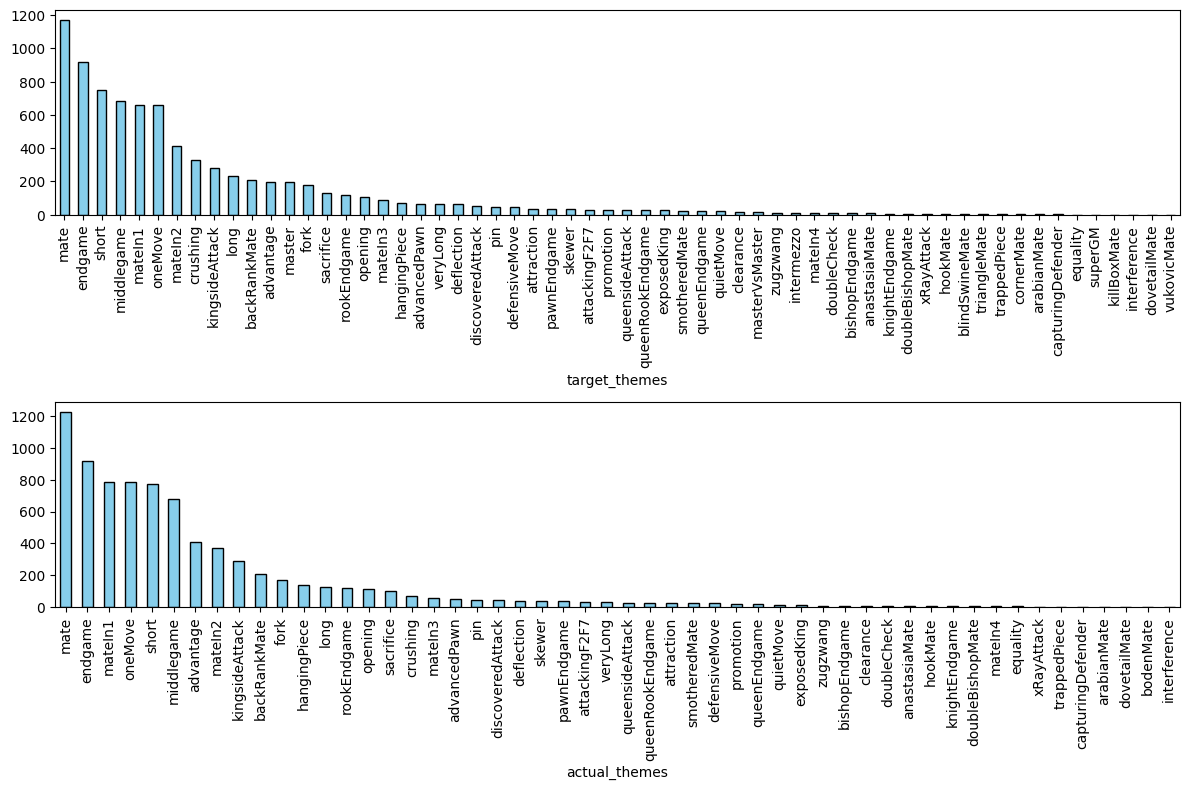

In [43]:
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
df.dropna()["target_themes"].explode().value_counts().sort_values(ascending=False).plot(kind="bar", color="skyblue", edgecolor="black")

plt.subplot(2, 1, 2)
df.dropna()["actual_themes"].explode().value_counts().sort_values(ascending=False).plot(kind="bar", color="skyblue", edgecolor="black")

plt.tight_layout()
plt.show()

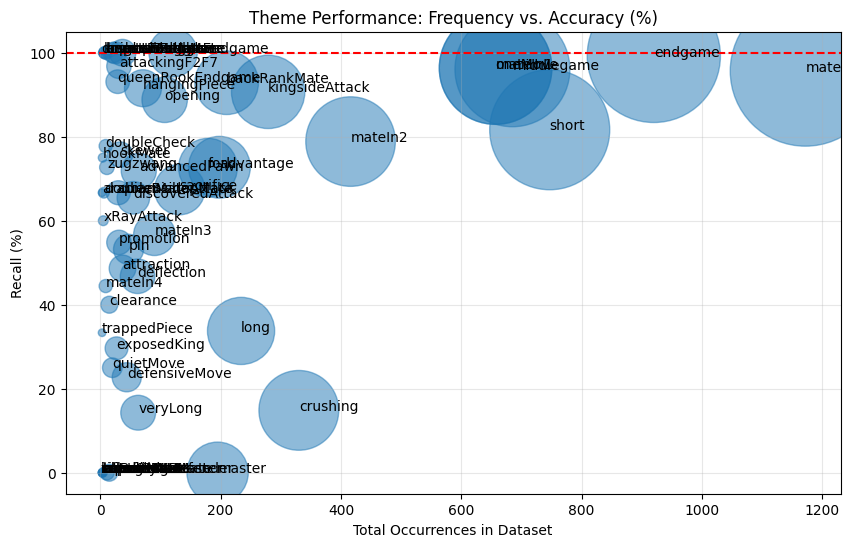

In [47]:
df['correct_themes'] = df.apply(
    lambda row: [theme for theme in row['target_themes'] if theme in row['actual_themes']], 
    axis=1
)

# 3. Aggregate frequencies for a side-by-side comparison
target_counts = df['target_themes'].explode().value_counts()
correct_counts = df['correct_themes'].explode().value_counts()

# Create a combined DataFrame for plotting
# Reindex ensures that even themes with zero correct hits are included
comparison_df = pd.DataFrame({
    'Total Target (Ground Truth)': target_counts,
    'Correct Hits (True Positives)': correct_counts
}).fillna(0).sort_values(by='Total Target (Ground Truth)', ascending=False)


# Calculate Percentage Accuracy (Recall) for each theme
comparison_df['Recall'] = (comparison_df['Correct Hits (True Positives)'] / 
                           comparison_df['Total Target (Ground Truth)']) * 100

plt.figure(figsize=(10, 6))
plt.scatter(comparison_df['Total Target (Ground Truth)'], comparison_df['Recall'], 
            s=comparison_df['Total Target (Ground Truth)']*10, alpha=0.5)

# Label the points
for i, txt in enumerate(comparison_df.index):
    plt.annotate(txt, (comparison_df['Total Target (Ground Truth)'].iat[i], comparison_df['Recall'].iat[i]))

plt.axhline(y=100, color='r', linestyle='--')
plt.title('Theme Performance: Frequency vs. Accuracy (%)')
plt.xlabel('Total Occurrences in Dataset')
plt.ylabel('Recall (%)')
plt.grid(True, alpha=0.3)
plt.show()

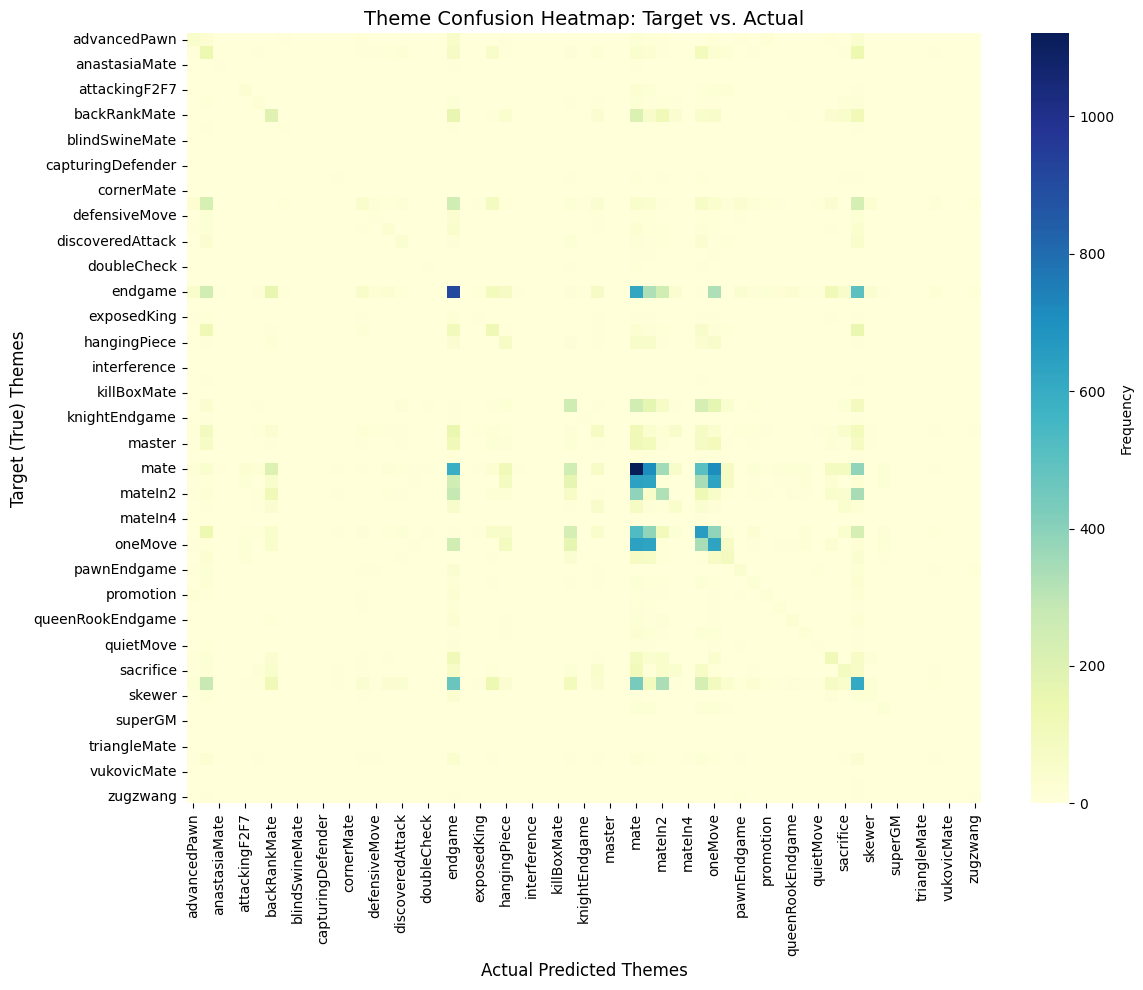

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer


all_themes = sorted(list(set(df["target_themes"].explode().dropna().unique()) | set(df["actual_themes"].explode().dropna().unique())))

mlb = MultiLabelBinarizer(classes=all_themes)

target_m = mlb.fit_transform(df["target_themes"])
actual_m = mlb.transform(df["actual_themes"])

conf_matrix = target_m.T @ actual_m
conf_df = pd.DataFrame(conf_matrix, index=all_themes, columns=all_themes)

plt.figure(figsize=(12, 10))
sns.heatmap(conf_df, annot=False, fmt="d", cmap="YlGnBu", cbar_kws={"label": "Frequency"})

plt.title("Theme Confusion Heatmap: Target vs. Actual", fontsize=14)
plt.xlabel("Actual Predicted Themes", fontsize=12)
plt.ylabel("Target (True) Themes", fontsize=12)
plt.tight_layout()
plt.show()

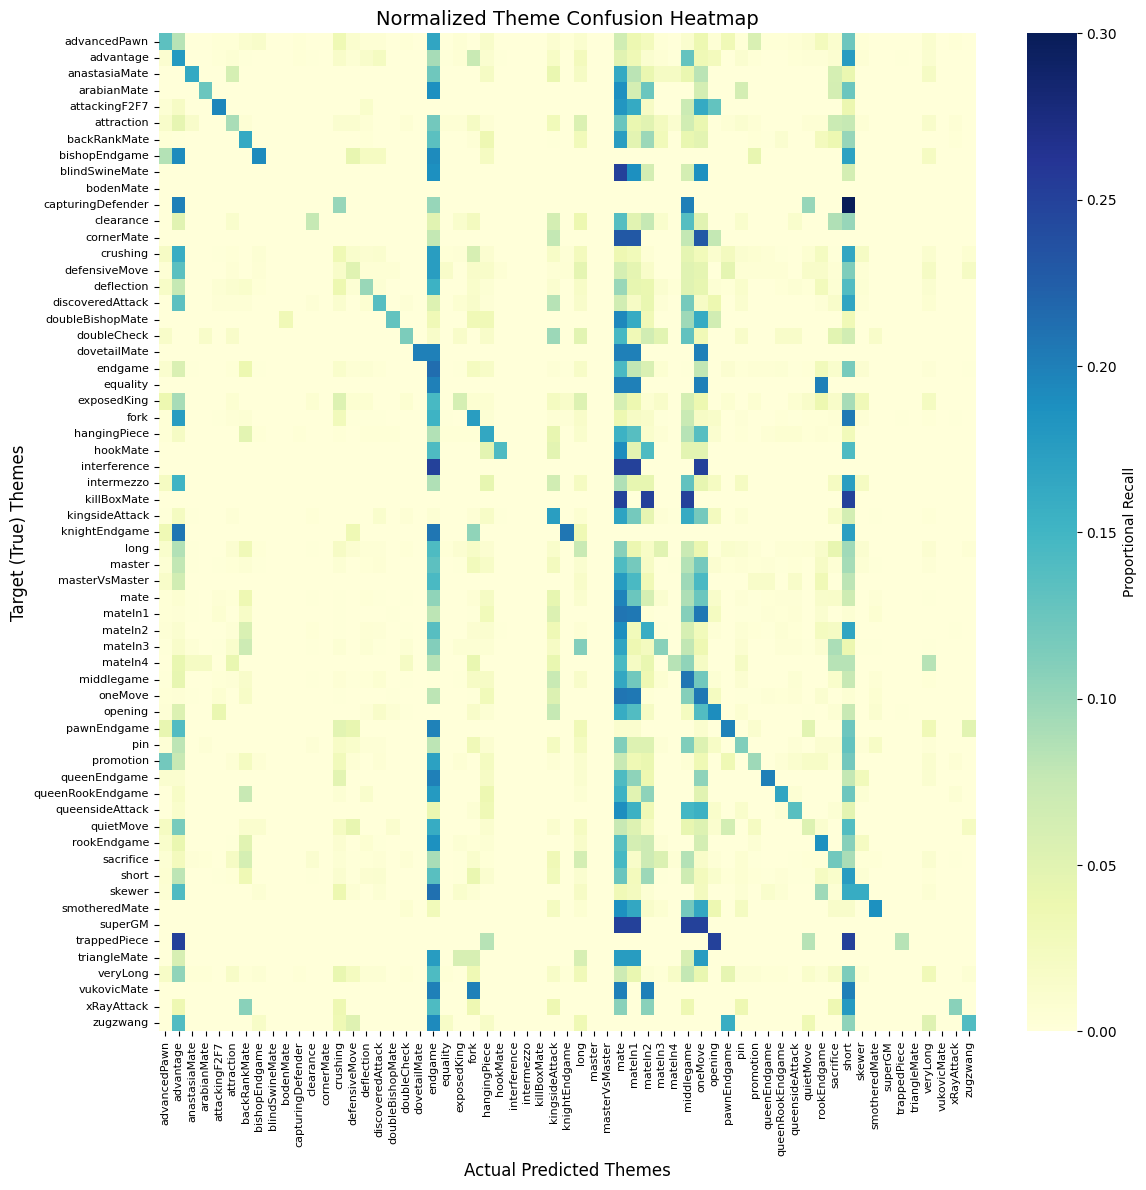

: 

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MultiLabelBinarizer


all_themes = sorted(list(set(df["target_themes"].explode().dropna().unique()) | set(df["actual_themes"].explode().dropna().unique())))

mlb = MultiLabelBinarizer(classes=all_themes)

target_m = mlb.fit_transform(df["target_themes"])
actual_m = mlb.transform(df["actual_themes"])

conf_matrix = target_m.T @ actual_m
conf_df = pd.DataFrame(conf_matrix, index=all_themes, columns=all_themes)

conf_df_norm = conf_df.div(conf_df.sum(axis=1), axis=0).fillna(0)

plt.figure(figsize=(12, 12))
sns.heatmap(
    conf_df_norm, 
    annot=False, 
    cmap="YlGnBu", 
    cbar_kws={"label": "Proportional Recall"},
    xticklabels=True, 
    yticklabels=True
)

plt.title("Normalized Theme Confusion Heatmap", fontsize=14)
plt.xlabel("Actual Predicted Themes", fontsize=12)
plt.ylabel("Target (True) Themes", fontsize=12)

plt.xticks(rotation=90, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

In [2]:
df.head()

,target_themes,target_rating,fen,is_legal,is_puzzle,counter_intuitive,actual_themes,predicted_rating,themes_match
46,"[backRankMate, endgame, mate, mateIn1, oneMove]",1052.0,5rk1/1r4pp/p7/2p1p3/P1RnN3/1P6/6PP/5Q1K b - - ...,True,True,False,"[endgame, mateIn1, mate, backRankMate, hanging...",657.043457,True
52,"[endgame, mate, mateIn1, oneMove, queenRookEnd...",1679.0,8/8/6pk/7p/5P2/5RKP/6R1/6q1 b - - 29 57,True,True,False,"[endgame, advantage, deflection, queenRookEndg...",1321.520386,False
55,"[crushing, defensiveMove, endgame, skewer, ver...",1455.0,6R1/8/1pr2k1K/5p2/p4P1p/8/2p5/2B5 w - - 2 48,True,True,False,"[endgame, advantage, skewer, short]",1027.698853,False
58,"[crushing, endgame, exposedKing, long, rookEnd...",1467.0,6k1/2R5/6K1/8/8/8/8/7r w - - 10 70,True,True,False,"[endgame, mateIn1, mate, rookEndgame, oneMove]",1051.989746,False
59,"[crushing, defensiveMove, endgame, long, pawnE...",2527.0,8/8/8/pp1k2pp/6P1/PP2K2P/8/8 b - - 0 41,True,True,False,"[endgame, advantage, defensiveMove, zugzwang, ...",2087.671143,True


In [10]:
print(df.explode("target_themes").groupby("target_themes")["is_legal"].mean())
print(df.explode("target_themes").groupby("target_themes")["is_puzzle"].mean())
print(df.explode("target_themes").groupby("target_themes")["counter_intuitive"].mean())

target_themes
advancedPawn      0.947107
advantage         0.974439
anastasiaMate     1.000000
arabianMate       1.000000
attackingF2F7     0.986486
                    ...   
underPromotion    0.666667
veryLong          0.964677
vukovicMate       1.000000
xRayAttack        0.972222
zugzwang          0.964602
Name: is_legal, Length: 66, dtype: float64
target_themes
advancedPawn      0.105785
advantage         0.068394
anastasiaMate     0.444444
arabianMate       0.375000
attackingF2F7     0.418919
                    ...   
underPromotion    0.000000
veryLong          0.076736
vukovicMate       0.166667
xRayAttack        0.138889
zugzwang          0.097345
Name: is_puzzle, Length: 66, dtype: float64
target_themes
advancedPawn       0.17452
advantage         0.135058
anastasiaMate     0.333333
arabianMate            0.0
attackingF2F7     0.082192
                    ...   
underPromotion         0.5
veryLong          0.170455
vukovicMate       0.166667
xRayAttack        0.057143
zugzwan

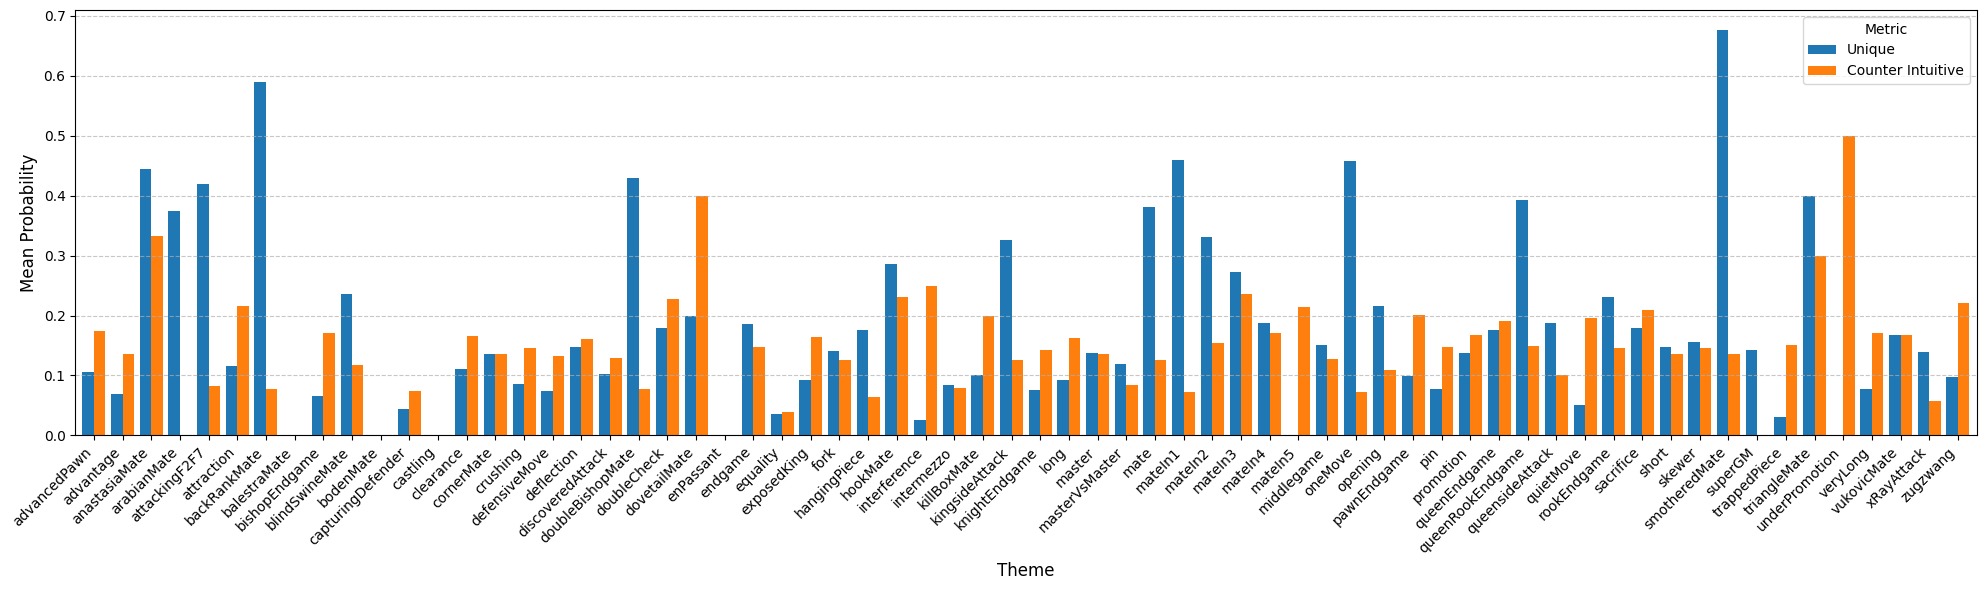

In [22]:
df_exploded = df.explode("target_themes")

# theme_stats = df_exploded.groupby("target_themes")[["is_puzzle", "counter_intuitive", "is_legal"]].mean()
theme_stats = df_exploded.groupby("target_themes")[["is_puzzle", "counter_intuitive"]].mean()

ax = theme_stats.plot(kind="bar", figsize=(20, 6), width=0.8)

plt.ylabel("Mean Probability", fontsize=12)
plt.xlabel("Theme", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.legend(["Unique", "Counter Intuitive", "Legal"], title="Metric")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()

C:\Users\aatus\AppData\Local\Temp\ipykernel_10332\454476119.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  theme_stats = df_exploded.groupby("target_themes").apply(calculate_conditional_metrics)


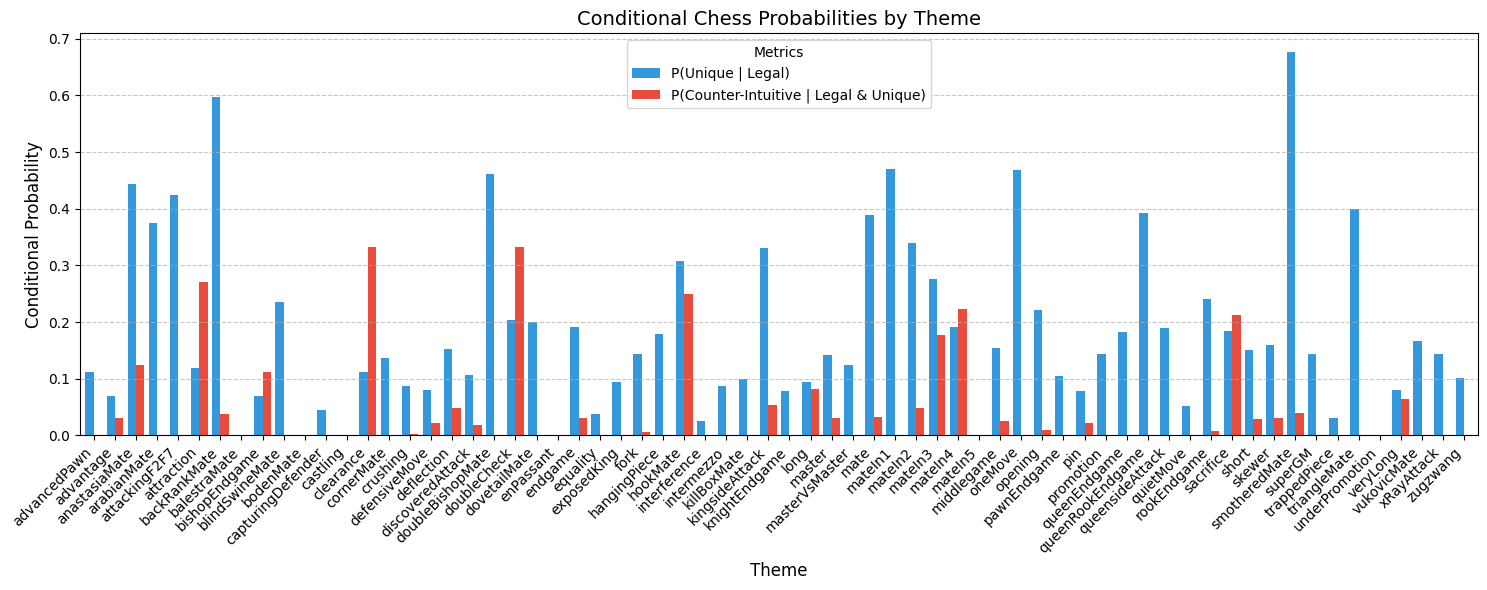

In [23]:
df_exploded = df.explode("target_themes")

# 1. Define a function to calculate these specific conditional probabilities
def calculate_conditional_metrics(group):
    # Metric 1: Unique Puzzle given Legal
    legal_mask = group['is_legal'] == True
    p_unique_given_legal = group.loc[legal_mask, 'is_puzzle'].mean()
    
    # Metric 2: Counter Intuitive given Legal AND Puzzle
    legal_and_puzzle_mask = (group['is_legal'] == True) & (group['is_puzzle'] == True)
    p_counter_given_both = group.loc[legal_and_puzzle_mask, 'counter_intuitive'].mean()
    
    return pd.Series({
        'P(Unique | Legal)': p_unique_given_legal,
        'P(Counter-Intuitive | Legal & Unique)': p_counter_given_both
    })

# 2. Apply the function to each theme
theme_stats = df_exploded.groupby("target_themes").apply(calculate_conditional_metrics)

# 3. Plotting
ax = theme_stats.plot(kind="bar", figsize=(15, 6), width=0.8, color=['#3498db', '#e74c3c'])

plt.ylabel("Conditional Probability", fontsize=12)
plt.xlabel("Theme", fontsize=12)
plt.title("Conditional Chess Probabilities by Theme", fontsize=14)
plt.xticks(rotation=45, ha="right")
plt.legend(title="Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()

plt.show()